## Build Toffoli Gate circuit in QpiAI Explorer Lab on Amazon Braket

In [1]:
#install amazon braket
%pip install amazon-braket-sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.7/313.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.7/191.7 kB 13.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.8/539.8 kB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 3.8 MB/s eta 0:00:00
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.2-py3-none-any.whl size=144548 sha256=55efa88e3b0ffa705d20065

In [2]:
#import relevant functions
from braket.circuits import Circuit
from braket.devices import LocalSimulator

### Build the Toffoli gate

The Toffoli gate is the CCX (also called CCNOT) gate, where the $X$ gate conditionally acts on a target qubit only when the two control qubits are in the state |1>. This is a three qubit gate composed of two control qubits and one target qubit.

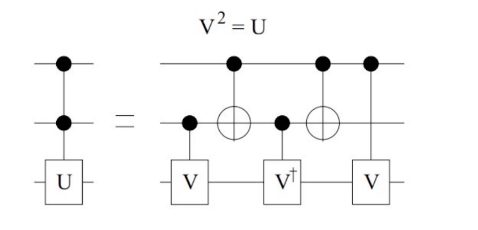

A general three qubit CCU gate can be broken down into two qubit gates in the above-mentioned manner. For the case of the Toffoli gate, unitary $V$ is the square root unitary of the $X$ gate and $V^{\dagger}$ is its adjoint.

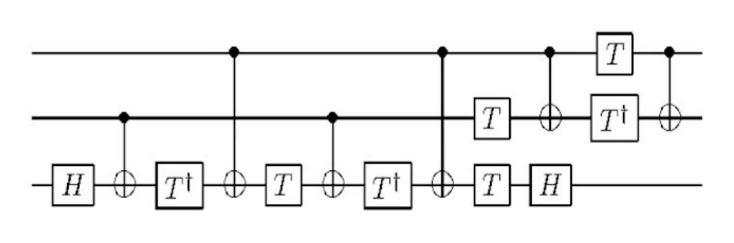

We can further decompose the  the Toffoli gate into single qubit gates and two qubit gates as shown above, and build a circuit composed of Hadmard, $T$, $T^{\dagger}$ and CNOTs.

In [3]:
#circuit to create a Toffoli gate circuit using the above method

def toffoli(c1,c2,tg,initial_state):

  circuit_1 = initial_state

  #apply Hadamard on the 3rd qubit

  circuit_1.h(tg)

  #apply CNOT on 2nd and 3rd qubits

  circuit_1.cnot(control=c2,target=tg)

  #apply T dagger on 3rd qubit

  circuit_1.ti(tg)

  #the subsequent gates as shown in the circuit diagram above can be written in a more compact manner as shown below

  circuit_1.cnot(control=c1,target=tg).t(tg).cnot(control=c2,target=tg).ti(tg).cnot(control=c1,target=tg)

  # continue applying the gates

  circuit_1.t(c2).t(tg).cnot(control=c1,target=c2).h(tg).t(c1).ti(c2).cnot(control=c1,target=c2)

  return circuit_1

#test for three qubits where control qubits are qubits 1 and 2 and target is qubit 3.

toffoli_gate = toffoli(c1=0,c2=1,tg=2,initial_state=Circuit())

print(toffoli_gate)

T  : │  0  │  1  │  2   │  3  │  4  │  5  │  6   │  7  │  8  │  9   │ 10  │
                                                              ┌───┐        
q0 : ──────────────────────●────────────────────────●─────●───┤ T ├────●───
                           │                        │     │   └───┘    │   
                           │               ┌───┐    │   ┌─┴─┐ ┌────┐ ┌─┴─┐ 
q1 : ─────────●────────────┼───────────●───┤ T ├────┼───┤ X ├─┤ Ti ├─┤ X ├─
              │            │           │   └───┘    │   └───┘ └────┘ └───┘ 
      ┌───┐ ┌─┴─┐ ┌────┐ ┌─┴─┐ ┌───┐ ┌─┴─┐ ┌────┐ ┌─┴─┐ ┌───┐ ┌───┐        
q2 : ─┤ H ├─┤ X ├─┤ Ti ├─┤ X ├─┤ T ├─┤ X ├─┤ Ti ├─┤ X ├─┤ T ├─┤ H ├────────
      └───┘ └───┘ └────┘ └───┘ └───┘ └───┘ └────┘ └───┘ └───┘ └───┘        
T  : │  0  │  1  │  2   │  3  │  4  │  5  │  6   │  7  │  8  │  9   │ 10  │


### Test the Toffoli circuit

We will test our Toffoli gate circuit using a 3-qubit GHZ state as our initial state, which is an equal superposition of the states |000> and |111>.

The Toffoli gate is Identity when both the control qubits are zero, and when both the control qubits are one, it performs a NOT operation on the third qubit. Hence, testing our toffoli circuit on the GHZ state will allow us to observe both these aspects of the gate, as |000> will remain unchanged (both control qubits are 0, so the operation is an Identity) and |111> will change to |110> (both control qubits are 1, so the Toffoli circuit performs a NOT operation on the third qubit).

Let us start by creating a GHZ-state circuit for three qubits. For detailed explanation on the theory for creating an n-qubit GHZ state circuit, refer to the QpiAI Explorer tutorials from Chapter 2 and the python notebooks for creating a GHZ state circuit.

In [4]:
# circuit to create an n-qubit GHZ state

import braket

#import relevant functions
from braket.circuits import Circuit
from braket.devices import LocalSimulator

def create_n_ghz_state(n):

    #initialize circuit

    circuit = Circuit()

    #put the first qubit in a uniform superposition of |0> and |1> state

    circuit.h(0)

    #performing cnot operations on subsequent qubits produces an n-qubit GHZ state

    for i in range(1,n):
        circuit.cnot(i-1,i)

    return circuit

In [6]:
#import create_n_ghz_state function from the python file for creating an n-qubit ghz state named n_ghz_state.py

#from nghzstate import create_n_ghz_state

#create a 3 qubit ghz state

ghz_state_3 = create_n_ghz_state(3)

In [7]:
# set up device
device = LocalSimulator()

#Importing the Toffoli gate circuit
toffoli_test_circuit = toffoli(c1=0,c2=1,tg=2,initial_state=ghz_state_3)

#run circuit using our function
result_1 = device.run(toffoli_test_circuit, shots=100).result()

# get measurement shots for our function
counts_1 = result_1.measurement_counts

# print counts
print(counts_1)


Counter({'000': 52, '110': 48})


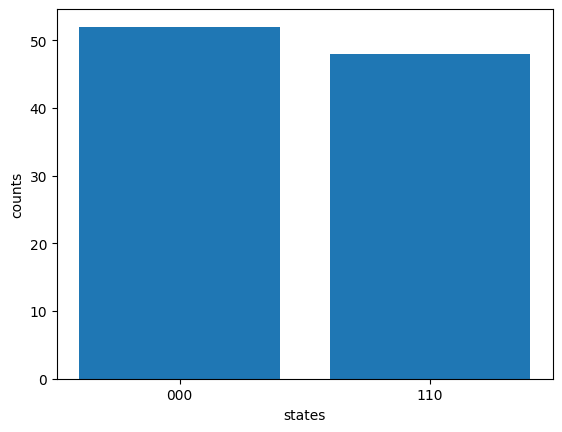

In [8]:
import matplotlib.pyplot as plt

# plot results of our function using Counter

plt.bar(counts_1.keys(), counts_1.values())
plt.xlabel('states')
plt.ylabel('counts')
plt.show()

### Inbuilt function for the Toffoli gate on Amazon braket

Amazon braket has an inbuilt function for implementing the Toffoli gate on three qubits, where again two are the control qubits and the third is the target. Let us see the implementation of this function on the three qubit GHZ state.

In [9]:
#test inbuilt ccnot function on our GHZ state circuit

inbuilt_toffoli = create_n_ghz_state(3).ccnot(0,1,2)
print(inbuilt_toffoli)

T  : │  0  │  1  │  2  │  3  │
      ┌───┐                   
q0 : ─┤ H ├───●───────────●───
      └───┘   │           │   
            ┌─┴─┐         │   
q1 : ───────┤ X ├───●─────●───
            └───┘   │     │   
                  ┌─┴─┐ ┌─┴─┐ 
q2 : ─────────────┤ X ├─┤ X ├─
                  └───┘ └───┘ 
T  : │  0  │  1  │  2  │  3  │


### Run the circuit with the inbuilt CCNOT Gate

In [10]:
# run circuit for inbuilt function
result_2 = device.run(inbuilt_toffoli, shots=1000).result()

# get measurement shots for inbuilt function
counts_2 = result_2.measurement_counts

# print counts
print(counts_2)


Counter({'110': 506, '000': 494})


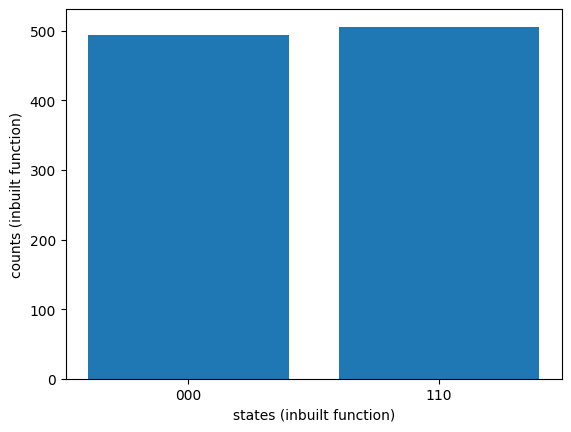

In [11]:
import matplotlib.pyplot as plt

# plot results of inbuilt function using Counter

plt.bar(counts_2.keys(), counts_2.values())
plt.xlabel('states (inbuilt function)')
plt.ylabel('counts (inbuilt function)')
plt.show()